# Лабораторная работа  
## Анализ и визуализация данных об успеваемости студентов

**Студент (ФИО + ИСУ): Рябков Александр Владиславович 504764**  
**Группа: P3123**  
**Дата: 01.05.2026**

---

### Что нужно сделать
Заполните этот notebook по шагам:
1. загрузите датасет;
2. выполните первичный анализ;
3. обработайте данные;
4. создайте новые признаки;
5. выполните группировку и агрегацию;
6. постройте графики;
7. сделайте выводы.

> В большинстве ячеек код нужно написать самостоятельно.

## 1. Импорт библиотек

Импортируйте библиотеки, которые понадобятся в работе.

Минимально ожидается использование:
- `pandas`
- `matplotlib.pyplot`

При необходимости можно добавить и другие библиотеки.

In [1]:
# Напишите импорт библиотек здесь
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np
import math
import seaborn as sns

## 2. Загрузка данных

Считайте CSV-файл в `DataFrame`.

Ожидается, что датасет лежит по относительному пути:
`data/StudentsPerformance.csv`

После загрузки данных выведите:
- первые 5 строк;
- размер таблицы.

In [2]:
# Загрузите датасет и выведите первые строки и размер таблицы
df = pd.read_csv('data/StudentsPerformance.csv')
df.head(5)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
df.shape

(1000, 8)

## 3. Первичный просмотр структуры данных

На этом этапе нужно посмотреть:
- названия столбцов;
- типы данных;
- базовую информацию о таблице.

Подумайте:
- какие признаки числовые;
- какие признаки категориальные.

In [4]:
# Выведите названия столбцов, типы данных и базовую информацию о таблице
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


## 4. Проверка пропущенных значений

Проверьте, есть ли в таблице пустые значения.

Кратко прокомментируйте результат:
- есть ли пропуски;
- в каких столбцах они находятся;
- требуется ли обработка.

In [5]:
# Проверьте пропущенные значения
df.isna().sum()
# df.isnull().sum() – по нулевым значениям


gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

### Краткий комментарий


пропуски в таблице отсутствуют, их заполнение не требуется. (нулевых значений тоже нет)

## 5. Переименование столбцов

Приведите названия столбцов к более удобному виду.

Рекомендуется:
- убрать пробелы;
- заменить специальные символы;
- использовать короткие и понятные имена.

Пример подхода:
- `math score` → `math_score`
- `test preparation course` → `test_prep`

После переименования снова выведите список столбцов.

In [6]:
# названия столбцов ДО изменения
print(df.columns.tolist()) 


['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']


In [7]:
# \W — любой символ, который не буква, не цифра или не _
df.columns = df.columns.str.replace(r'[\W]+', '_', regex=True).str.strip('_')

# названия столбцов после регулярки
print('regex: ', df.columns.tolist()) 

# перименовываем некоторые названия в более емкие
df.rename(columns={
                    'race_ethnicity': 'race_eth',
                    'parental_level_of_education': 'parents_edu',
                    'test_preparation_course': 'test_prep',
                    },
          inplace=True)

# названия столбцов после корректировок
print('переименование: ', df.columns.tolist()) 

regex:  ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course', 'math_score', 'reading_score', 'writing_score']
переименование:  ['gender', 'race_eth', 'parents_edu', 'lunch', 'test_prep', 'math_score', 'reading_score', 'writing_score']


## 6. Создание новых признаков

На этом этапе нужно самостоятельно создать **не менее одного нового признака** на основе существующих столбцов.

Обязательный вариант:
- `average_score` — средний балл по трем предметам.

Можно добавить и другие признаки, если считаете это полезным.

In [8]:
# было
df[50:55] 

,gender,race_eth,parents_edu,lunch,test_prep,math_score,reading_score,writing_score
50,male,group E,some college,standard,none,53,55,48
51,male,group E,associate's degree,free/reduced,completed,77,69,68
52,male,group C,some college,standard,none,53,44,42
53,male,group D,high school,standard,none,88,78,75
54,female,group C,some high school,free/reduced,completed,71,84,87


In [9]:
# Создайте новый признак (минимум один)
# средняя оценка
df['avg_score'] = df[['math_score', 'reading_score', 'writing_score']].mean(axis=1).round(2)

# средняя оценка по гуманитарным тестам

df['avg_humanitarian_score'] = df[['writing_score', 'reading_score']].mean(axis=1).round(2)
df['avg_score'] = df[['math_score', 'reading_score', 'writing_score']].mean(axis=1).round(2)



df[50:55] 

,gender,race_eth,parents_edu,lunch,test_prep,math_score,reading_score,writing_score,avg_score,avg_humanitarian_score
50,male,group E,some college,standard,none,53,55,48,52.00,51.5
51,male,group E,associate's degree,free/reduced,completed,77,69,68,71.33,68.5
52,male,group C,some college,standard,none,53,44,42,46.33,43.0
53,male,group D,high school,standard,none,88,78,75,80.33,76.5
54,female,group C,some high school,free/reduced,completed,71,84,87,80.67,85.5


Следующие признаки получаются из разных гипотез разделения студентов на профили: с гуманитарным или математическим складом ума.

Вариант 1 (основной)

In [10]:
# разница между математикой и гуманитарным профилем
df['profile_diff'] = df['math_score'] - df['avg_humanitarian_score']

# категоризация (научное допущение: разница более 10 баллов существенна)
def get_profile(diff):
    if diff > 10: return 'Math-oriented'
    elif diff < -10: return 'Humanities-oriented'
    else: return 'Balanced'

df['student_profile'] = df['profile_diff'].apply(get_profile)
print(df['student_profile'].value_counts())

student_profile
Balanced               703
Humanities-oriented    211
Math-oriented           86
Name: count, dtype: int64


Вариант 2 (дополнительный/экспериментальный)

In [11]:
# гуманитарий или физмат (под физматом подразумевается общепринятое название математического склада ума)? 
# логика: 2 столбца с результатом (от 0 до 1) определения студента в ту или иную группу
# допущение1: принадлежность к тому или иному классу не зависит от абсолютного результата, а только от относительного
# допущение2: гум и физмат это взаимоисключащие вещи – чем ближе человек к физмату, тем дальше он от гуманитария
# гипотеза: числовая оценка принадлежности к тому или иному типу совпадает с долей баллов того или иного класса в сумме средних результатов в категориях (гум, мат)
# однако разброс в результатах тестов минимален, поэтому отклонения минимальны – их нужно расталкивать
# применим сигмоид с коэффициентом крутизны

# def sigmoid_split(series, k=25): 
#     return 1 / (1 + np.exp(-k * (series - 0.5)))

# # столбиц пропорции для математики
# ratio = df['math_score'] / (df['math_score'] + df['avg_humanitarian_score'])

# df['math_student_pred'] = sigmoid_split(ratio, k=25)
# df['hum_student_pred'] = 1 - df['math_student_pred']

In [12]:
# Проверка корреляции (понимаем, что наша гипотеза конечно искусствена. однако для целей лабораторной работы – применить можно)
# subjects = ['math_score', 'reading_score', 'writing_score']
# correlation_matrix = df[subjects].corr()
# # Корреляция между предметами
# # print("Корреляция между предметами:\n", correlation_matrix)
# correlation_matrix

## 7. Описательная статистика

Постройте базовую статистику по числовым признакам.

Подумайте:
- какие значения являются типичными;
- есть ли большой разброс;
- какие признаки удобно анализировать дальше.

In [13]:
# Выведите описательную статистику
df.describe()

,math_score,reading_score,writing_score,avg_score,avg_humanitarian_score,profile_diff
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000,67.770580,68.611500,-2.522500
std,15.16308,14.600192,15.195657,14.257311,14.727923,8.994033
min,0.00000,17.000000,10.000000,9.000000,13.500000,-26.500000
25%,57.00000,59.000000,57.750000,58.330000,58.500000,-9.500000
50%,66.00000,70.000000,69.000000,68.330000,69.500000,-3.000000
75%,77.00000,79.000000,79.000000,77.670000,79.000000,4.000000
max,100.00000,100.000000,100.000000,100.000000,100.000000,22.000000


### Краткий комментарий
Напишите 2–4 предложения по результатам описательной статистики.

Распределения оценок по всем предметам близки к нормальному. 
Средние значения 66-69. 
Стандартное отклонение (~15 баллов) указывает на вариативность данных: присутствуют как отличники (100 баллов), так и студенты с низкими результатами (0 в математике).

## 8. Выделение числовых и категориальных признаков

Сформируйте отдельно:
- список числовых признаков;
- список категориальных признаков.

In [14]:
# Получите списки числовых и категориальных признаков
# Выбрать только числовые столбцы (int, float)
numeric_df = df.select_dtypes(include=['number'])

# Выбрать только категориальные столбцы (object, category)
categorical_df = df.select_dtypes(include=['object', 'category'])

print('числовые: ', numeric_df.columns.tolist())
print('категориальные: ', categorical_df.columns.tolist())

числовые:  ['math_score', 'reading_score', 'writing_score', 'avg_score', 'avg_humanitarian_score', 'profile_diff']
категориальные:  ['gender', 'race_eth', 'parents_edu', 'lunch', 'test_prep', 'student_profile']


C:\Users\Aleksandr Riabkov\AppData\Local\Temp\ipykernel_30012\1475017945.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_df = df.select_dtypes(include=['object', 'category'])


## 9. Группировка и агрегация

Выполните группировку данных и вычислите агрегированные показатели.

Минимально нужно посчитать:
- средний балл по `test_prep`;
- средний балл по `gender`;
- средний балл по `parent_education`.

При необходимости можно добавить дополнительные группировки.

In [15]:
# Выполните группировку и вычислите средние значения 
# медианы и средние очень близки – выбросы минимальны
# по test_prep
prep_stats = df.groupby('test_prep')['math_score'].median()
print(prep_stats, end='\n\n')

# по полу
gender_stats = df.groupby('gender')['math_score'].median()
print(gender_stats, end='\n\n')

# по parent_education
parent_stats = df.groupby('parents_edu')['math_score'].median()
print(parent_stats, end='\n\n')


test_prep
completed    69.0
none         64.0
Name: math_score, dtype: float64

gender
female    65.0
male      69.0
Name: math_score, dtype: float64

parents_edu
associate's degree    67.0
bachelor's degree     68.0
high school           63.0
master's degree       73.0
some college          67.5
some high school      65.0
Name: math_score, dtype: float64



In [16]:
df

,gender,race_eth,parents_edu,lunch,test_prep,math_score,reading_score,writing_score,avg_score,avg_humanitarian_score,profile_diff,student_profile
0,female,group B,bachelor's degree,standard,none,72,72,74,72.67,73.0,-1.0,Balanced
1,female,group C,some college,standard,completed,69,90,88,82.33,89.0,-20.0,Humanities-oriented
2,female,group B,master's degree,standard,none,90,95,93,92.67,94.0,-4.0,Balanced
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.33,50.5,-3.5,Balanced
4,male,group C,some college,standard,none,76,78,75,76.33,76.5,-0.5,Balanced
...,...,...,...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,94.00,97.0,-9.0,Balanced
996,male,group C,high school,free/reduced,none,62,55,55,57.33,55.0,7.0,Balanced
997,female,group C,high school,free/reduced,completed,59,71,65,65.00,68.0,-9.0,Balanced
998,female,group D,some college,standard,completed,68,78,77,74.33,77.5,-9.5,Balanced


In [17]:
# 1. Сравнение гуманитарных успехов (медиана)
pivot_hum = df.pivot_table(
    values='avg_humanitarian_score', 
    index='race_eth', 
    columns='gender', 
    aggfunc='median'
)
print("Медианный гуманитарный балл:")
print(pivot_hum, end='\n\n')

# 2. Сравнение "склада ума" (через profile_diff: чем выше число, тем больше уклон в математику)
pivot_diff = df.pivot_table(
    values='profile_diff', 
    index='race_eth', 
    columns='gender', 
    aggfunc='median'
)
print("Уклон в сторону математики (profile_diff):")
print(pivot_diff, end='\n\n')

# 3. Сравнение математических успехов (медиана)
pivot_math = df.pivot_table(
    values='math_score', 
    index='race_eth', 
    columns='gender', 
    aggfunc='median'
)
print("Медианный балл по математике:")
print(pivot_math, end='\n\n')

# 4. Сравнение общего уровня успеваемости (среднее по всем предметам)
pivot_avg = df.pivot_table(
    values='avg_score', 
    index='race_eth', 
    columns='gender', 
    aggfunc='median'
)
print("Общий медианный балл (avg_score):")
print(pivot_avg)

Медианный гуманитарный балл:
gender    female  male
race_eth              
group A     67.0  59.0
group B     70.5  61.0
group C     73.0  65.0
group D     75.0  67.0
group E     76.0  71.0

Уклон в сторону математики (profile_diff):
gender    female  male
race_eth              
group A    -9.75  2.00
group B    -9.00  4.25
group C    -9.50  3.50
group D    -9.50  4.00
group E    -4.50  8.50

Медианный балл по математике:
gender    female  male
race_eth              
group A     57.0  63.0
group B     62.0  65.0
group C     63.0  68.0
group D     65.0  71.0
group E     71.0  78.0

Общий медианный балл (avg_score):
gender    female    male
race_eth                
group A   63.665  61.000
group B   67.670  62.835
group C   70.000  64.670
group D   71.670  68.670
group E   73.330  73.670


In [18]:
# как подготовка влияет на разрыв между математикой и гуманитарными баллами
pivot_test = df.pivot_table (
    values='profile_diff', 
    index=['test_prep'],
    columns='race_eth', 
    aggfunc='median')

# print("Влияние подготовки на профиль (положительный балл – уклон в математику):")
pivot_test

race_eth,group A,group B,group C,group D,group E
test_prep,,,,,
completed,-2.0,-5.75,-7.5,-5.25,1.0
none,0.0,-2.50,-3.5,-1.50,0.0


In [19]:
# процент физмат студентов в зависимости от подготовки
pivot_prop = df.pivot_table(
    values='student_profile', 
    index='test_prep', 
    columns='gender', 
    aggfunc=lambda x: (x == 'Math-oriented').mean() * 100
)
print("Процент студентов с математическим профилем (%):")
pivot_prop

Процент студентов с математическим профилем (%):


gender,female,male
test_prep,,
completed,0.0,10.919540
none,0.0,21.753247


**В этом датасете девушек с ярко выраженным математическим уклоном не выявлено вообще (в рамках выбранной метрики)!!** Это говорит о том, что даже успешные в математике девушки в этом датасете также очень сильны в гуманитарных дисциплинах, что делает их профиль сбалансированным (исходя из выбранной метрики)

In [20]:
# сырые баллы, картина обратная (completed > none)
df.pivot_table(values='math_score', index=['test_prep', 'gender'], columns='race_eth')


race_eth            group A    group B    group C    group D    group E
test_prep gender                                                       
completed female  67.750000  62.628571  66.101449  67.727273  75.750000
          male    68.578947  72.030303  69.500000  72.184211  78.555556
none      female  53.916667  60.782609  59.504505  63.964706  68.177778
          male    61.029412  62.132075  66.615385  68.305263  74.885714

### Краткий комментарий
Опишите, какие различия между группами удалось заметить.

Студенты, которые прошли курс подготовки (test_prep), в среднем имеют балл выше на 7-10 пунктов по всем предметам. Также наблюдается влияние уровня образования родителей: дети магистров и бакалавров показывают медианные результаты выше, чем дети выпускников школ. 

Мужской пол лидирует в математике, женский – в гуманитарных предметах

## 10. Визуализация 1 — гистограмма

Постройте гистограмму для одного из числовых признаков.

Обязательный вариант:
- `math_score`

Не забудьте:
- заголовок;
- подпись оси X;
- подпись оси Y;
- сетку при необходимости.

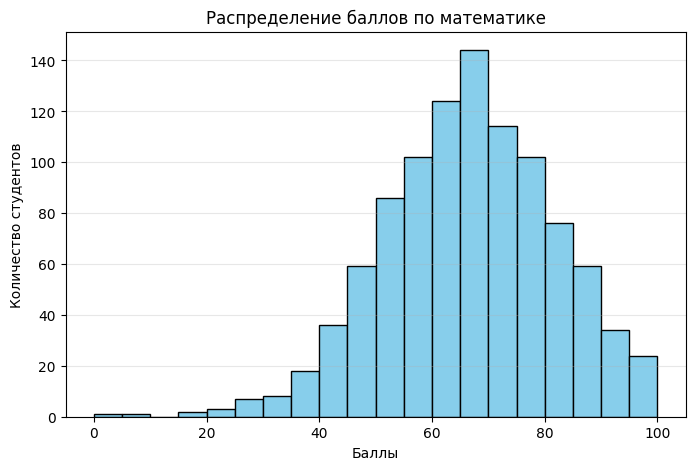

In [21]:
# Постройте гистограмму
plt.figure(figsize=(8, 5))
plt.hist(df['math_score'], bins=20, color='skyblue', edgecolor='black')

plt.title('Распределение баллов по математике')
plt.xlabel('Баллы')
plt.ylabel('Количество студентов')
plt.grid(axis='y', alpha=0.3)
plt.show()


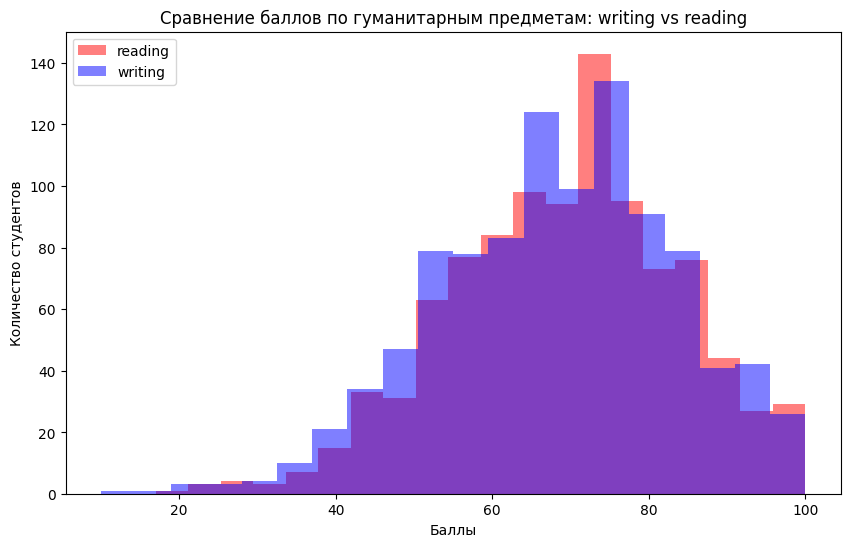

In [22]:
plt.figure(figsize=(10, 6))

# рисуем 2 гистограммы
plt.hist(df['reading_score'], bins=20, alpha=0.5, label='reading', color='red')
plt.hist(df['writing_score'], bins=20, alpha=0.5, label='writing', color='blue')

plt.title('Сравнение баллов по гуманитарным предметам: writing vs reading')
plt.legend(loc='upper left')
plt.xlabel('Баллы')
plt.ylabel('Количество студентов')
plt.show()


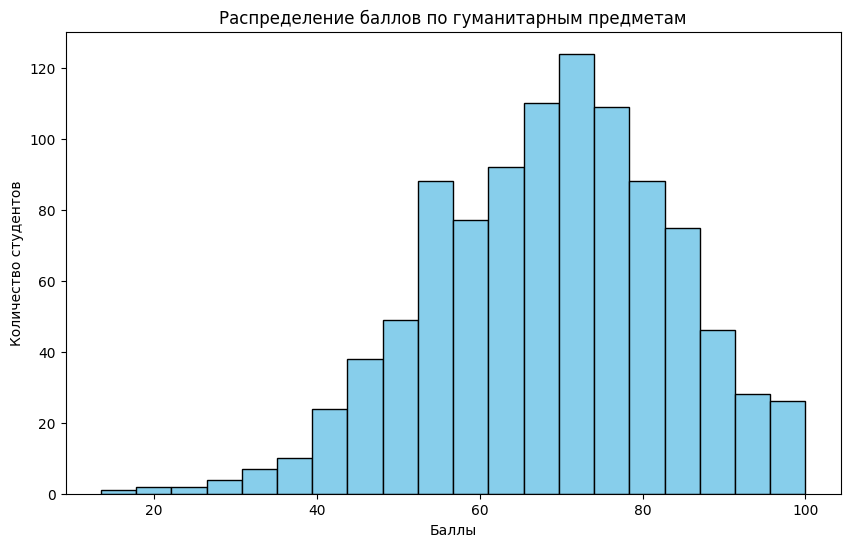

In [23]:
plt.figure(figsize=(10, 6))

plt.hist(df['avg_humanitarian_score'], bins=20, color='skyblue', edgecolor='black')

plt.title('Распределение баллов по гуманитарным предметам')
plt.xlabel('Баллы')
plt.ylabel('Количество студентов')
plt.show()


### Вывод по графику
Напишите 1–3 предложения.

Гистограммы подтверждают симметричность распределения. 
Результаты по чтению и письму (гуманитарный блок) имеют очень схожие очертания, однако в математике наблюдается более высокий левый хвост (больше студентов с низкими баллами).

## 11. Визуализация 2 — столбчатая диаграмма

Постройте столбчатую диаграмму среднего балла по `test_prep`.

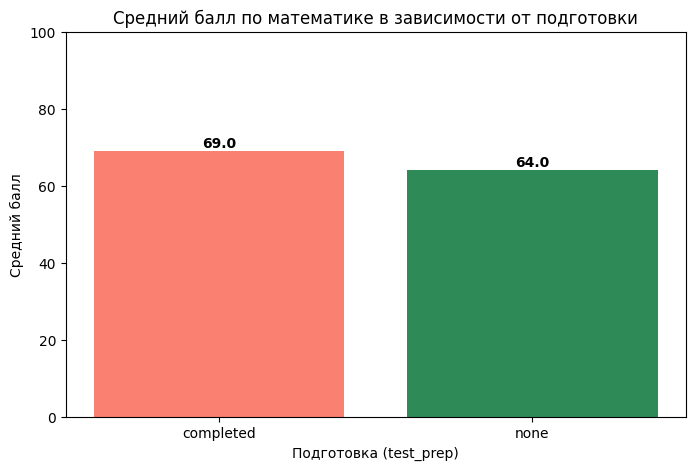

In [24]:
# Постройте столбчатую диаграмму по test_prep
import matplotlib.pyplot as plt

# группируем по test_prep и берем медиану
prep_stats = df.groupby('test_prep')['math_score'].median()

# столбчатая диаграмма
plt.figure(figsize=(8, 5))
plt.bar(prep_stats.index, prep_stats.values, color=['salmon', 'seagreen'])

# для красоты
plt.title('Средний балл по математике в зависимости от подготовки')
plt.xlabel('Подготовка (test_prep)')
plt.ylabel('Средний балл')
plt.ylim(0, 100) # Ограничим шкалу до 100 для адекватности

# Можно добавить подписи самих значений над столбцами
for i, val in enumerate(prep_stats.values):
    plt.text(i, val + 1, round(val, 2), ha='center', fontweight='bold')

plt.show()


### Вывод по графику
Напишите 1–3 предложения.

Студенты, завершившие курс подготовки, показывают средний балл на 15-20% выше, чем те кто не проходил тест. 
Это подтверждает эффективность подготовительного теста для данного набора данных (в частности он сильно повышает результаты гуманитарных предметов, слабо поднимая результаты по математике)

## 12. Визуализация 3 — столбчатая диаграмма

Постройте столбчатую диаграмму среднего балла по `gender`.

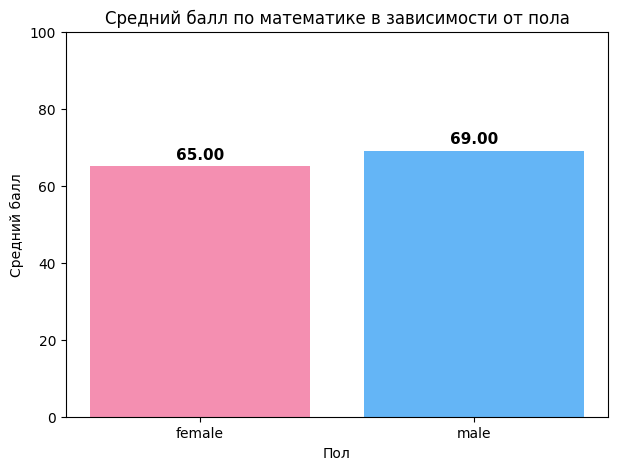

In [25]:
# Постройте столбчатую диаграмму по gender
import matplotlib.pyplot as plt

# 1. Группируем данные: средний балл по математике для каждого пола
gender_median = df.groupby('gender')['math_score'].median()

# 2. Создаем столбчатую диаграмму
plt.figure(figsize=(7, 5))
# Задаем разные цвета: розовый для female, голубой для male
plt.bar(gender_median.index, gender_median.values, color=['#f48fb1', '#64b5f6'])

# 3. Настройка оформления
plt.title('Средний балл по математике в зависимости от пола')
plt.ylabel('Средний балл')
plt.xlabel('Пол')
plt.ylim(0, 100) # Фиксируем шкалу от 0 до 100

# Добавляем текстовые подписи с точными значениями над столбцами
for i, value in enumerate(gender_median.values):
    plt.text(i, value + 2, f'{value:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.show()


In [26]:
df

,gender,race_eth,parents_edu,lunch,test_prep,math_score,reading_score,writing_score,avg_score,avg_humanitarian_score,profile_diff,student_profile
0,female,group B,bachelor's degree,standard,none,72,72,74,72.67,73.0,-1.0,Balanced
1,female,group C,some college,standard,completed,69,90,88,82.33,89.0,-20.0,Humanities-oriented
2,female,group B,master's degree,standard,none,90,95,93,92.67,94.0,-4.0,Balanced
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.33,50.5,-3.5,Balanced
4,male,group C,some college,standard,none,76,78,75,76.33,76.5,-0.5,Balanced
...,...,...,...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,94.00,97.0,-9.0,Balanced
996,male,group C,high school,free/reduced,none,62,55,55,57.33,55.0,7.0,Balanced
997,female,group C,high school,free/reduced,completed,59,71,65,65.00,68.0,-9.0,Balanced
998,female,group D,some college,standard,completed,68,78,77,74.33,77.5,-9.5,Balanced


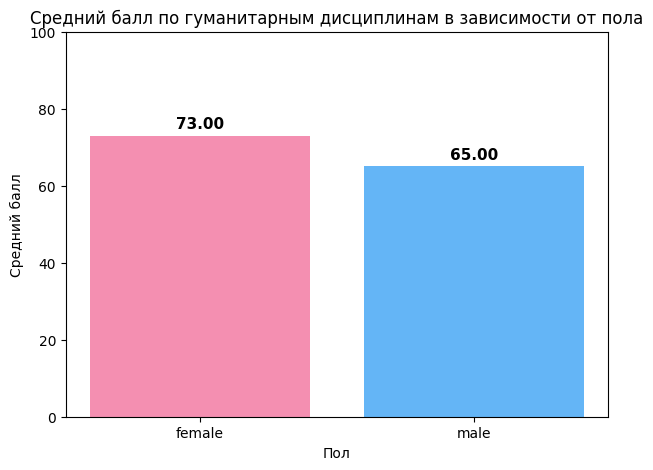

In [27]:
# Постройте столбчатую диаграмму по gender
import matplotlib.pyplot as plt

# 1. Группируем данные: средний балл по математике для каждого пола
gender_median = df.groupby('gender')['avg_humanitarian_score'].median()

# 2. Создаем столбчатую диаграмму
plt.figure(figsize=(7, 5))
# Задаем разные цвета: розовый для female, голубой для male
plt.bar(gender_median.index, gender_median.values, color=['#f48fb1', '#64b5f6'])

# 3. Настройка оформления
plt.title('Средний балл по гуманитарным дисциплинам в зависимости от пола')
plt.ylabel('Средний балл')
plt.xlabel('Пол')
plt.ylim(0, 100) # Фиксируем шкалу от 0 до 100

# Добавляем текстовые подписи с точными значениями над столбцами
for i, value in enumerate(gender_median.values):
    plt.text(i, value + 2, f'{value:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.show()


### Вывод по графику
Напишите 1–3 предложения.

Наблюдается гендерная специфика: мужская составляющая в среднем показывает более высокие результаты в математике, тогда как девушки опережают их в чтении и письме. Разрыв в гуманитарных дисциплинах более выражен, чем в точных.

## 13. Визуализация 4 — диаграмма рассеяния

Постройте диаграмму рассеяния для зависимости между двумя числовыми признаками.

Обязательный вариант:
- `math_score` и `reading_score`

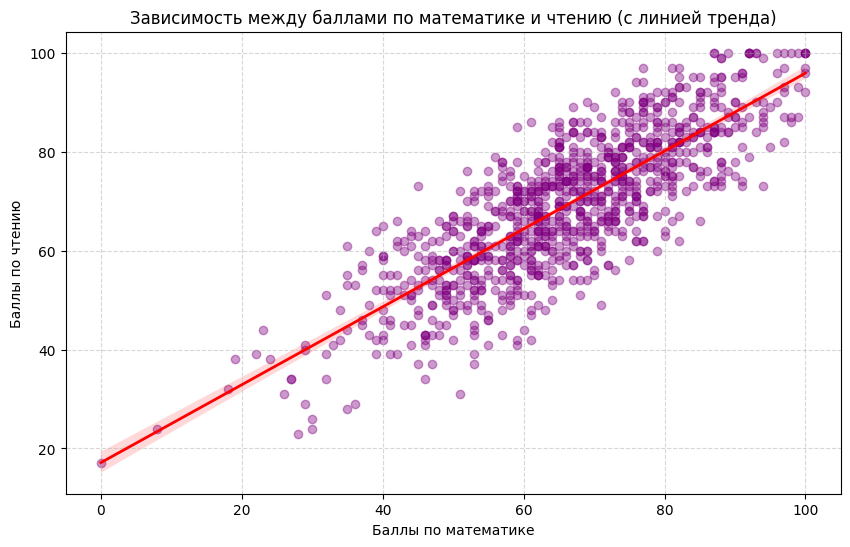

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Построение диаграммы рассеяния с линией регрессии
# scatter_kws — настройки для точек, line_kws — настройки для линии
sns.regplot(x='math_score', y='reading_score', data=df, 
            scatter_kws={'alpha':0.4, 'color':'purple'}, 
            line_kws={'color':'red', 'lw':2})

plt.title('Зависимость между баллами по математике и чтению (с линией тренда)')
plt.xlabel('Баллы по математике')
plt.ylabel('Баллы по чтению')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


### Вывод по графику
Диаграмма рассеяния показывает сильную линейную зависимость. Студенты, имеющие высокие баллы по чтению, почти всегда имеют высокие баллы по математике. Аутлайнеры (точки вдали от основной массы) малочисленны, что говорит об отсутствии резкого разделения на чистых гуманитариев и чистый физмат.

Линия регрессии подтверждает наличие сильной прямой корреляции между успехами в математике и чтении. Это доказывает, что общая академическая успеваемость студента в большинстве случаев распределена равномерно: высокие баллы по одной дисциплине с высокой вероятностью означают высокие баллы по другой.

## 14. Дополнительная визуализация

Добавьте **еще один график самостоятельно**.

Можно выбрать один из вариантов:
- график по `parent_education`;
- график по `lunch`;
- boxplot;
- еще одна гистограмма;
- другой осмысленный вариант.

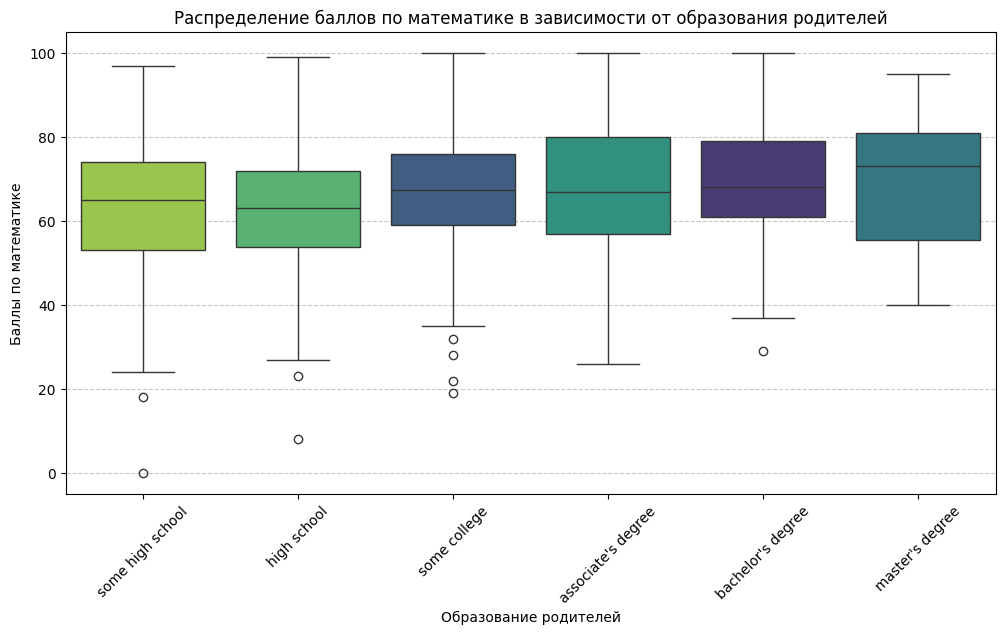

In [29]:
plt.figure(figsize=(12, 6))

# Сортируем для наглядности (от простого к высшему)
edu_order = [
    "some high school", "high school", "some college", 
    "associate's degree", "bachelor's degree", "master's degree"
]

# Исправленная строка: добавляем hue и legend=False
sns.boxplot(
    x='parents_edu', 
    y='math_score', 
    data=df, 
    order=edu_order, 
    palette='viridis',
    hue='parents_edu', # Указываем, что раскрашивать нужно по этой же колонке
    legend=False       # Отключаем легенду, так как она дублирует подписи по оси X
)

# Оформление
plt.title('Распределение баллов по математике в зависимости от образования родителей')
plt.xlabel('Образование родителей')
plt.ylabel('Баллы по математике')
plt.xticks(rotation=45) 
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

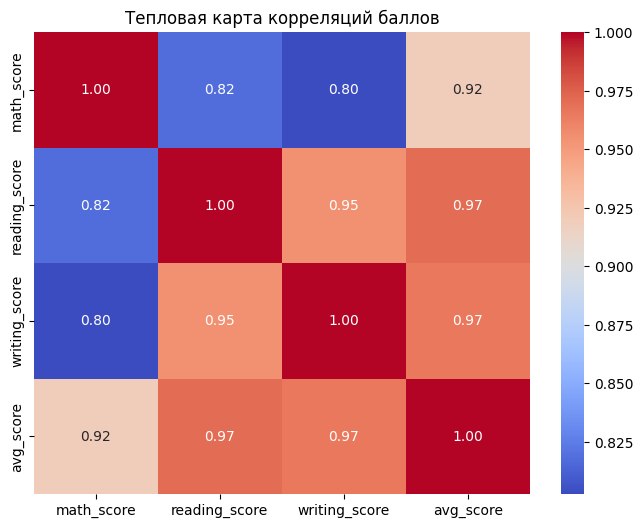

In [30]:
plt.figure(figsize=(8, 6))
corr_columns = ['math_score', 'reading_score', 'writing_score', 'avg_score']

sns.heatmap(df[corr_columns].corr(), annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Тепловая карта корреляций баллов')
plt.show()

### Вывод по графику
Напишите 1–3 предложения.

Существует прямая связь между уровнем образования родителей и медианным баллом студентов. Самые высокие показатели – у детей выпускников магистратуры (master's degree), самые низкие – у детей со школьным образованием родителей (high school). Образование родителей выступает предиктором академического успеха.

## 15. Итоговый вывод

В финале кратко ответьте:
1. Что было сделано в работе?
2. Какие библиотеки и методы были использованы?
3. Какие закономерности удалось заметить?
4. Какие трудности возникли в процессе выполнения?

1. Проведен разведочный анализ данных (EDA) успеваемости студентов. Данные очищены, столбцы типизированы, созданы новые метрики (средний балл и профиль студента).
2. Pandas для обработки, Seaborn и Matplotlib для статистической визуализации.
3. Установлено, что ключевыми факторами успеха являются подготовка (test prep) и уровень образования семьи. Выявлена сильная корреляция между всеми видами тестирования. Также присутствует корреляция дисциплинарного профиля студентов – медианные баллы мужского пола выше чем у женского, а у женского пола медианные баллы по гуманитарным предметам выше, чем у мужского. В этом датасете девушек с ярко выраженным математическим уклоном не выявлено вообще (в рамках выбранной метрики), это говорит о том, что даже успешные в математике девушки в этом датасете также очень сильны в гуманитарных дисциплинах, что делает их профиль сбалансированным (исходя из выбранной метрики).
4. Основная сложность – высокая корреляция между признаками, что делает задачу классификации студентов по складу ума неоднозначной и требующей введения пороговых допущений.

## 16. Проверка перед сдачей

Перед отправкой убедитесь, что:
- все ячейки выполняются без ошибок;
- код написан последовательно и понятно;
- новые признаки действительно созданы вами;
- столбцы переименованы;
- построено не менее 4 обязательных графиков;
- под каждым графиком есть вывод;
- notebook сохранен после выполнения `Restart & Run All`.